## 1. Load Processed Dataset

In [39]:
import pandas as pd

df = pd.read_csv(
    "../Data/Processed/risk_scored_dataset.csv"
)

df.head()

,Financial_Loss,Operational_Disruption,Reputation_Damage_Score,Incident_Response_Time,Recovery_Time,Cybersecurity_Budget,Employee_Training,Use_of_MFA,Data_Backup_Availability,Technical_Score,Human_Score,Org_Score,Impact_Score,Risk_Score,Risk_Level
0,0.008056,0.761208,0.666667,0.392150,0.432813,0.105304,True,True,True,1.0,1,0.105304,0.371293,0.475692,Low
1,0.758048,0.597195,0.750000,0.838926,0.338468,0.078036,True,True,True,1.0,1,0.078036,0.690398,0.905447,High
2,0.665349,0.288264,0.666667,0.242147,0.518697,0.193583,True,True,True,1.0,1,0.193583,0.533210,0.653528,High
3,0.715633,0.561428,0.333333,0.798344,0.245326,0.705562,True,True,True,1.0,1,0.705562,0.569572,0.499592,Medium
4,0.425708,0.562274,0.583333,0.656293,0.300294,0.263583,True,True,True,1.0,1,0.263583,0.495063,0.575862,Medium


## 2. Dataset Overview

In [40]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 1000
Columns: 15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Financial_Loss            1000 non-null   float64
 1   Operational_Disruption    1000 non-null   float64
 2   Reputation_Damage_Score   1000 non-null   float64
 3   Incident_Response_Time    1000 non-null   float64
 4   Recovery_Time             1000 non-null   float64
 5   Cybersecurity_Budget      1000 non-null   float64
 6   Employee_Training         1000 non-null   bool   
 7   Use_of_MFA                1000 non-null   bool   
 8   Data_Backup_Availability  1000 non-null   bool   
 9   Technical_Score           1000 non-null   float64
 10  Human_Score               1000 non-null   int64  
 11  Org_Score                 1000 non-null   float64
 12  Impact_Score              1000 non-null   float64
 13  Risk_Score                1000 non-null  

## 3. Feature Selection

In [41]:
X = df[
    [
        "Financial_Loss",
        "Operational_Disruption",
        "Reputation_Damage_Score",
        "Incident_Response_Time",
        "Recovery_Time",
        "Cybersecurity_Budget",
        "Employee_Training",
        "Use_of_MFA",
        "Data_Backup_Availability",
        "Technical_Score",
        "Human_Score",
        "Org_Score"
    ]
]

y = df["Risk_Level"]

print(X.shape)
print(y.shape)
print(X.columns.tolist())

(1000, 12)
(1000,)
['Financial_Loss', 'Operational_Disruption', 'Reputation_Damage_Score', 'Incident_Response_Time', 'Recovery_Time', 'Cybersecurity_Budget', 'Employee_Training', 'Use_of_MFA', 'Data_Backup_Availability', 'Technical_Score', 'Human_Score', 'Org_Score']


## 4. Data Splitting

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


(800, 12)
(200, 12)


## 5. Model Evaluation Function

In [43]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test
):

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    print(
        f"\nModel: {model.__class__.__name__}"
    )

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print(
        classification_report(
            y_test,
            predictions
        )
    )

    return accuracy

## 6. Decision Tree Model


Model: DecisionTreeClassifier
Accuracy: 0.6500
              precision    recall  f1-score   support

        High       0.76      0.71      0.73        68
         Low       0.82      0.61      0.70        66
      Medium       0.48      0.64      0.55        66

    accuracy                           0.65       200
   macro avg       0.69      0.65      0.66       200
weighted avg       0.69      0.65      0.66       200



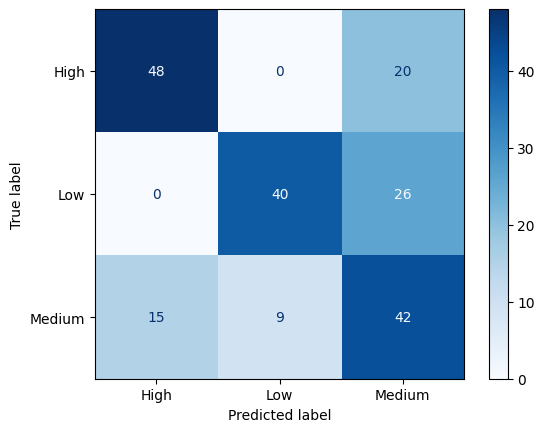

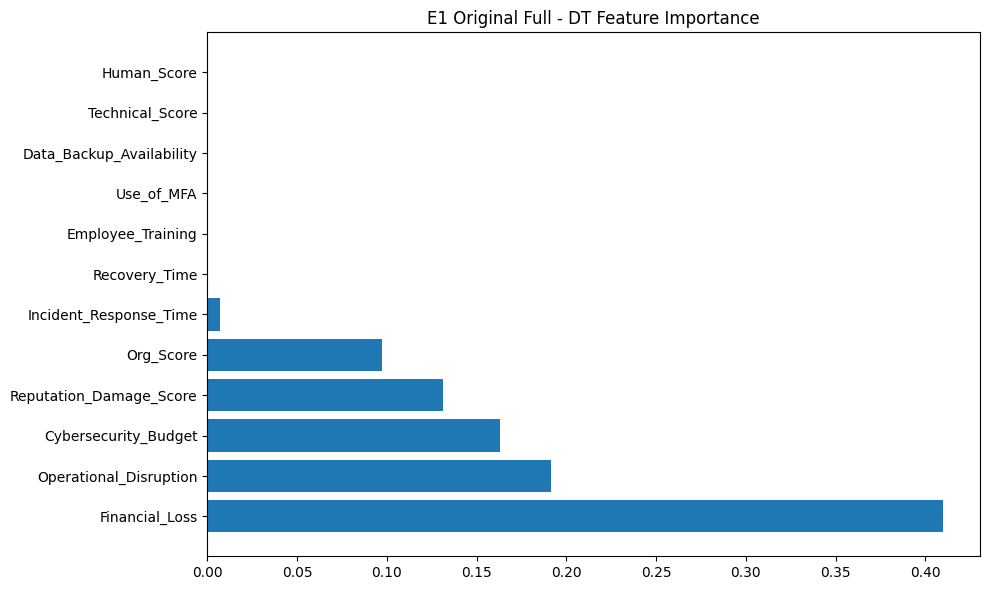

Decision Tree Model Saved Successfully


In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import joblib

dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_accuracy = evaluate_model(
    dt_model,
    X_train,
    X_test,
    y_train,
    y_test
)

# Confusion Matrix
dt_pred = dt_model.predict(X_test)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    cmap="Blues"
)

disp.figure_.savefig(
    "../Outputs/Confusion_Matrices/E1_Original_Full_DT.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(
    importance["Feature"],
    importance["Importance"]
)

ax.set_title(
    "E1 Original Full - DT Feature Importance"
)

fig.tight_layout()

fig.savefig(
    "../Outputs/Feature_Importance/E1_Original_Full_DT_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show(fig)

joblib.dump(
    dt_model,
    "../Models/decision_tree.pkl"
)

print("Decision Tree Model Saved Successfully")

## 7. Random Forest


Model: RandomForestClassifier
Accuracy: 0.8300
              precision    recall  f1-score   support

        High       0.87      0.81      0.84        68
         Low       0.87      0.94      0.91        66
      Medium       0.74      0.74      0.74        66

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



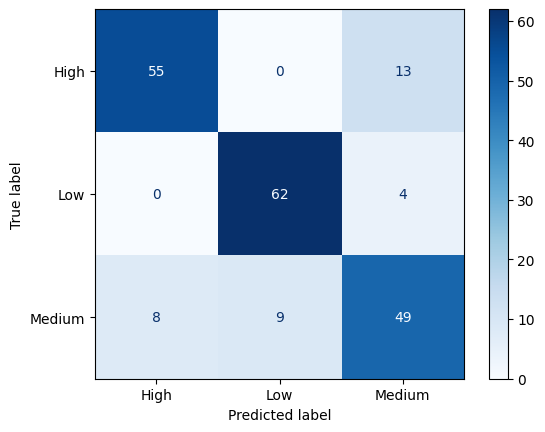

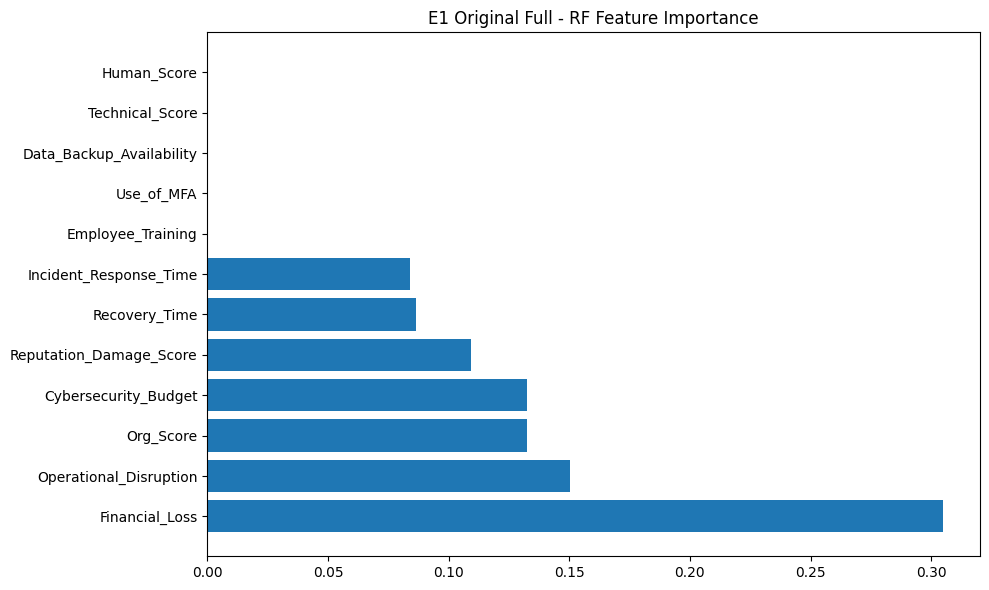

Random Forest Model Saved Successfully


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import joblib

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_accuracy = evaluate_model(
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

# Confusion Matrix
rf_pred = rf_model.predict(X_test)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Blues"
)

disp.figure_.savefig(
    "../Outputs/Confusion_Matrices/E1_Original_Full_RF.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(
    importance["Feature"],
    importance["Importance"]
)

ax.set_title(
    "E1 Original Full - RF Feature Importance"
)

fig.tight_layout()

fig.savefig(
    "../Outputs/Feature_Importance/E1_Original_Full_RF_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show(fig)

joblib.dump(
    rf_model,
    "../Models/random_forest.pkl"
)

print("Random Forest Model Saved Successfully")

## 8. XGBoost Model

XGBOOST RESULTS
Accuracy: 0.8700

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92        68
           1       0.89      0.88      0.89        66
           2       0.79      0.83      0.81        66

    accuracy                           0.87       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.87      0.87       200


Confusion Matrix:
[[61  0  7]
 [ 0 58  8]
 [ 4  7 55]]


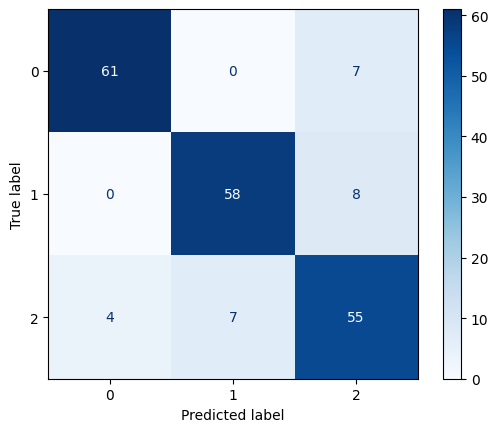


Feature Importance:
                     Feature  Importance
0             Financial_Loss    0.270524
5       Cybersecurity_Budget    0.214619
1     Operational_Disruption    0.179946
2    Reputation_Damage_Score    0.174324
4              Recovery_Time    0.084950
3     Incident_Response_Time    0.075637
6          Employee_Training    0.000000
7                 Use_of_MFA    0.000000
8   Data_Backup_Availability    0.000000
9            Technical_Score    0.000000
10               Human_Score    0.000000
11                 Org_Score    0.000000


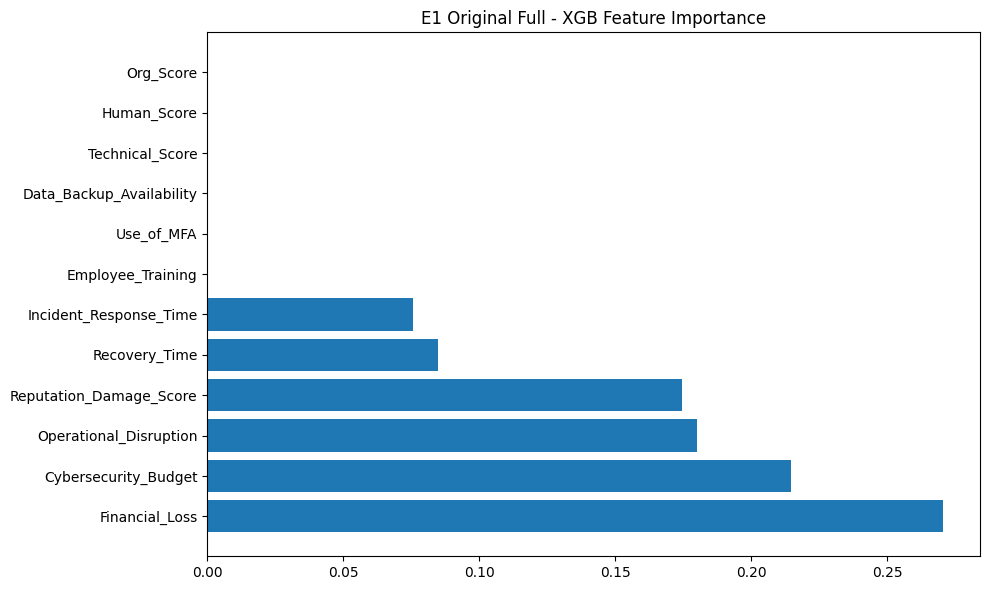

XGBoost Model Saved Successfully


In [46]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

import pandas as pd
import matplotlib.pyplot as plt
import joblib

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    df["Risk_Level"]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train,
    y_train
)

y_pred = xgb_model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

# Confusion Matrix Figure
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

disp.figure_.savefig(
    "../Outputs/Confusion_Matrices/E1_Original_Full_XGB.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(
    importance["Feature"],
    importance["Importance"]
)

ax.set_title(
    "E1 Original Full - XGB Feature Importance"
)

fig.tight_layout()

fig.savefig(
    "../Outputs/Feature_Importance/E1_Original_Full_XGB_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show(fig)

joblib.dump(
    xgb_model,
    "../Models/xgboost.pkl"
)

print("XGBoost Model Saved Successfully")

## 9. Export Result To CSV

In [47]:
import pandas as pd

results = pd.DataFrame({
    "Experiment": ["E1_Original_Full"],
    "DT": [dt_accuracy * 100],
    "RF": [rf_accuracy * 100],
    "XGB": [accuracy * 100]
})

print(results)

results.to_csv(
    "/Users/prakashpanta/Desktop/Cyber_Security_Risk_Assessment/Outputs/Tables/All_Results.csv",
    index=False
)


         Experiment    DT    RF   XGB
0  E1_Original_Full  65.0  83.0  87.0
